# Nutrient Data Plotting

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
from sklearn.linear_model import LinearRegression
import numpy as np
import re
import matplotlib as mpl

mpl.rcParams["font.family"] = "Arial"

In [22]:
# Load CSV
nut_dic = {}
folder = '../3_data/1_nutrients/data/'

for file in glob.glob(os.path.join(folder,'*.txt')):
    name = os.path.basename(file).replace('.txt', '').strip()
    print(name)
    df = pd.read_csv(file, delimiter='\t')
    print(df)
    nut_dic[name] = df

nutrients_filtered = {
    key: df for key, df in nut_dic.items()
    if "filtered" in key.lower()
}

nutrients_unfiltered = {
    key: df for key, df in nut_dic.items()
    if "filtered" not in key.lower()
}

clio59_Nuts_filtered
    Depth  Nitrate+NO2  Ammonium  Phosphate  Silicate
0      50        0.284     2.786      0.107     0.590
1      50        0.040     1.368      0.009     0.651
2      50        0.144     2.308      0.222     0.541
3      50        0.040     0.851      0.009     0.235
4     150       11.686     0.531      0.634     3.710
5     200       15.203     0.517      0.831     5.711
6     300       22.088     0.631      1.355     9.997
7     500       23.274     0.688      1.508    13.073
8     800       13.054     0.719      0.753    10.320
9      15        0.040     1.008      0.013     0.353
10     30        0.040     0.022      0.009     0.352
11     70        0.040     0.320      0.009     0.414
12     80        0.153     0.209      0.009     0.476
13     90        0.052     0.221      0.009     0.555
14    100        0.088     0.475      0.009     1.180
15    110        0.527     0.362      0.009     0.552
16    125        3.756     0.346      0.139     1.379
17    1

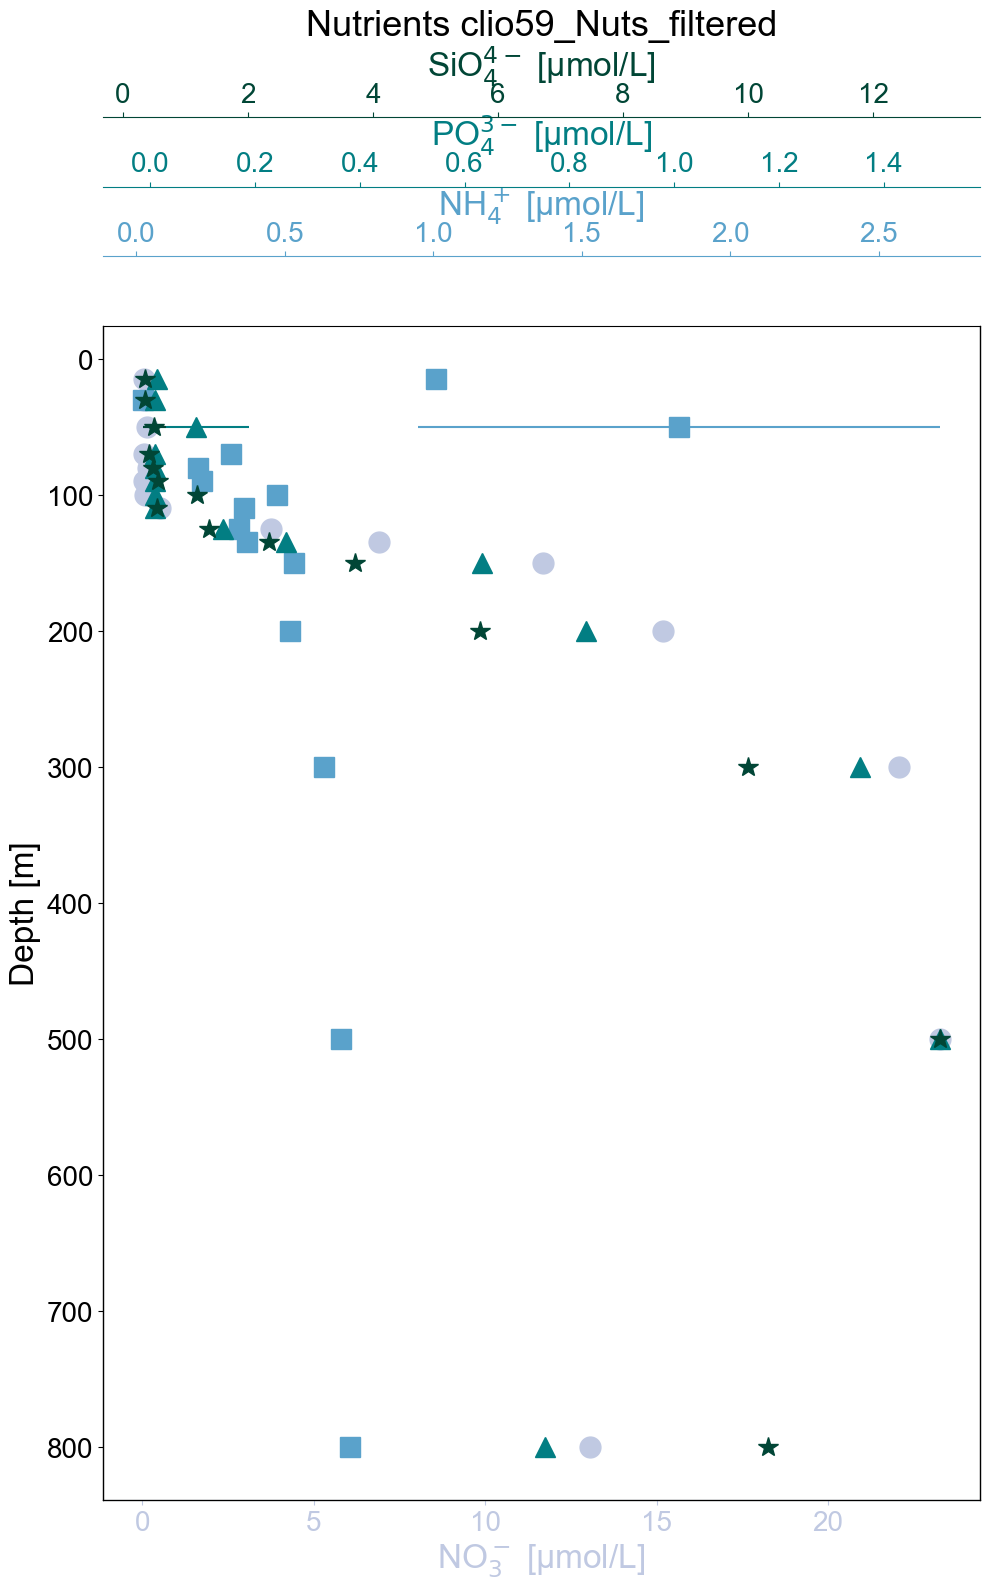

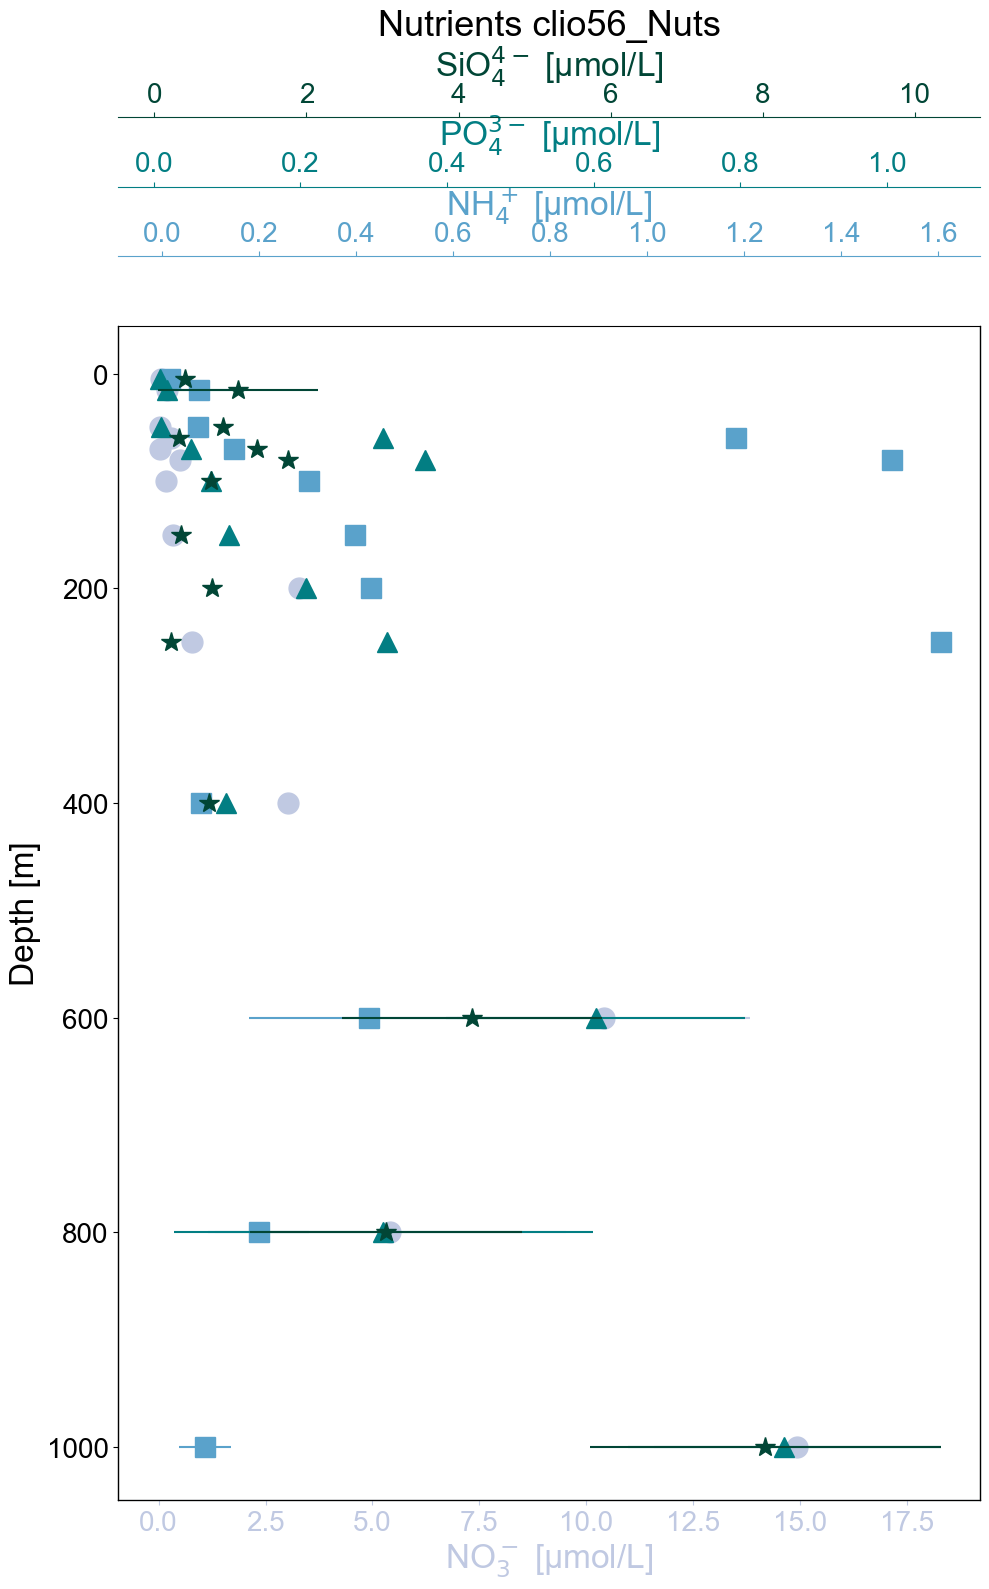

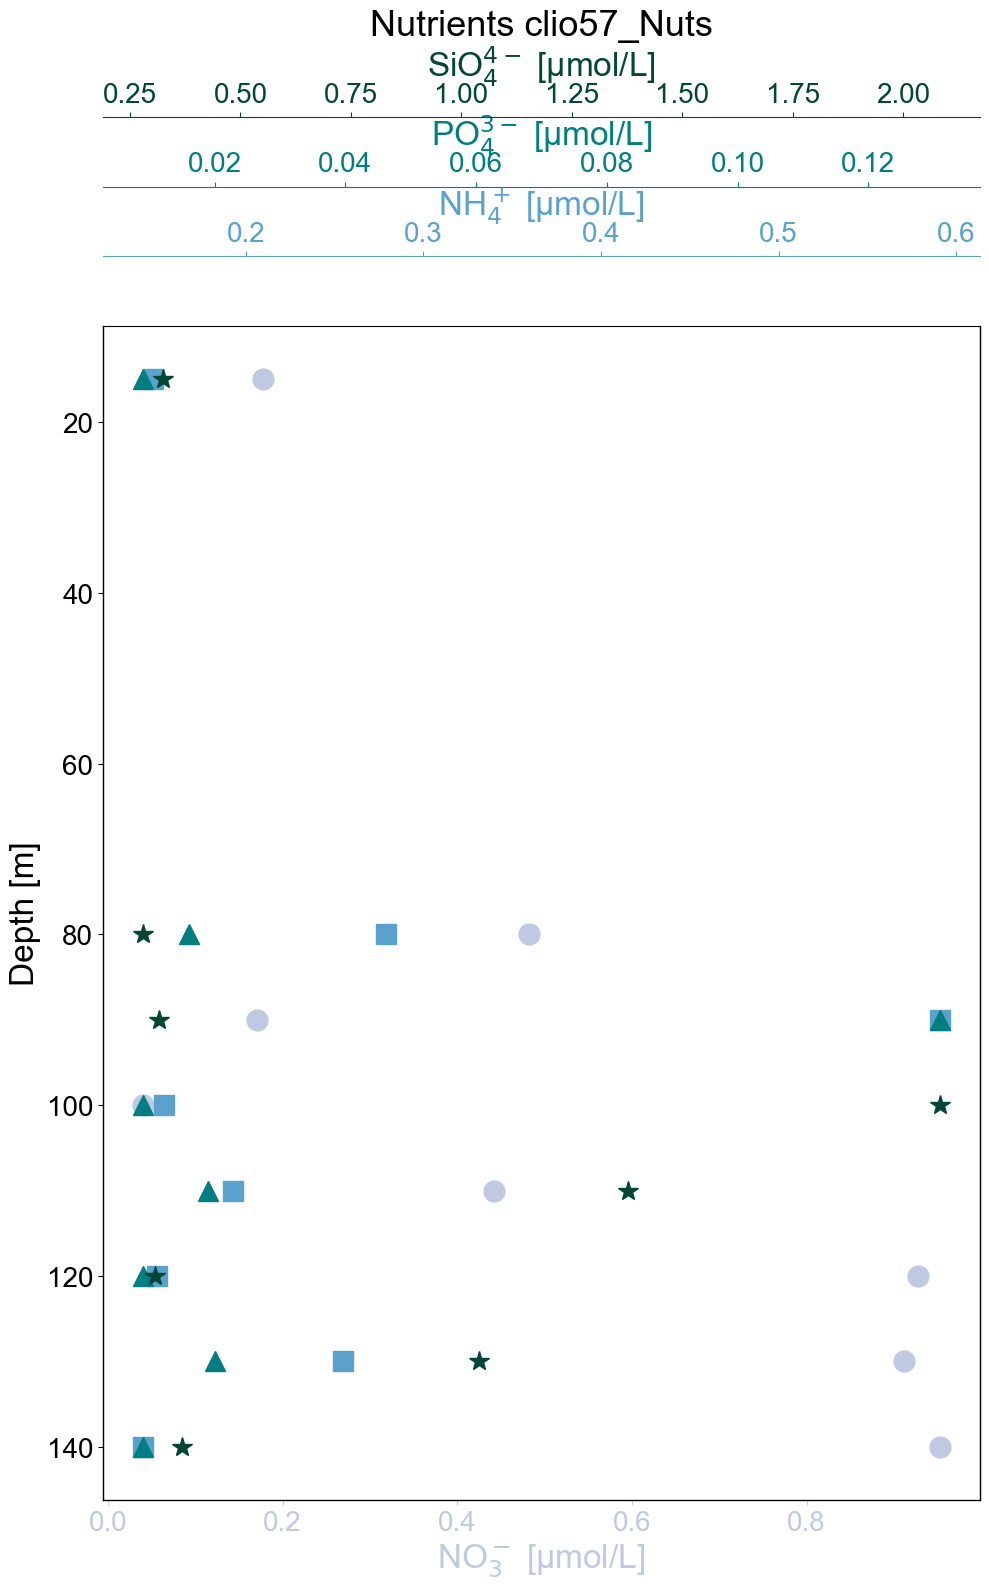

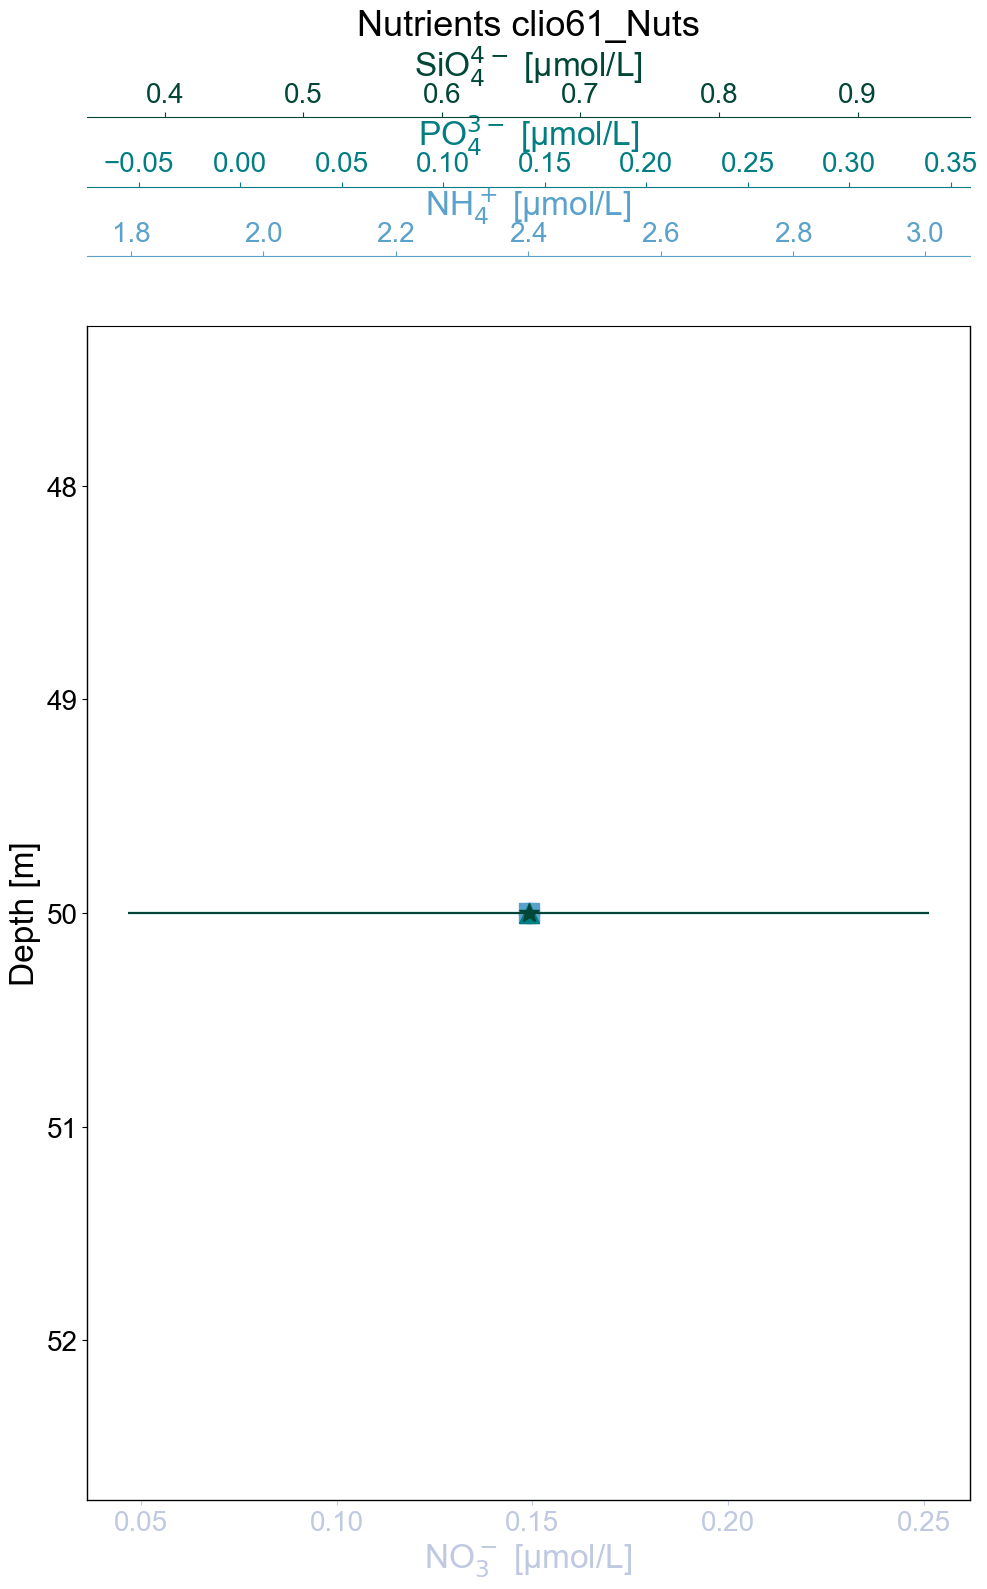

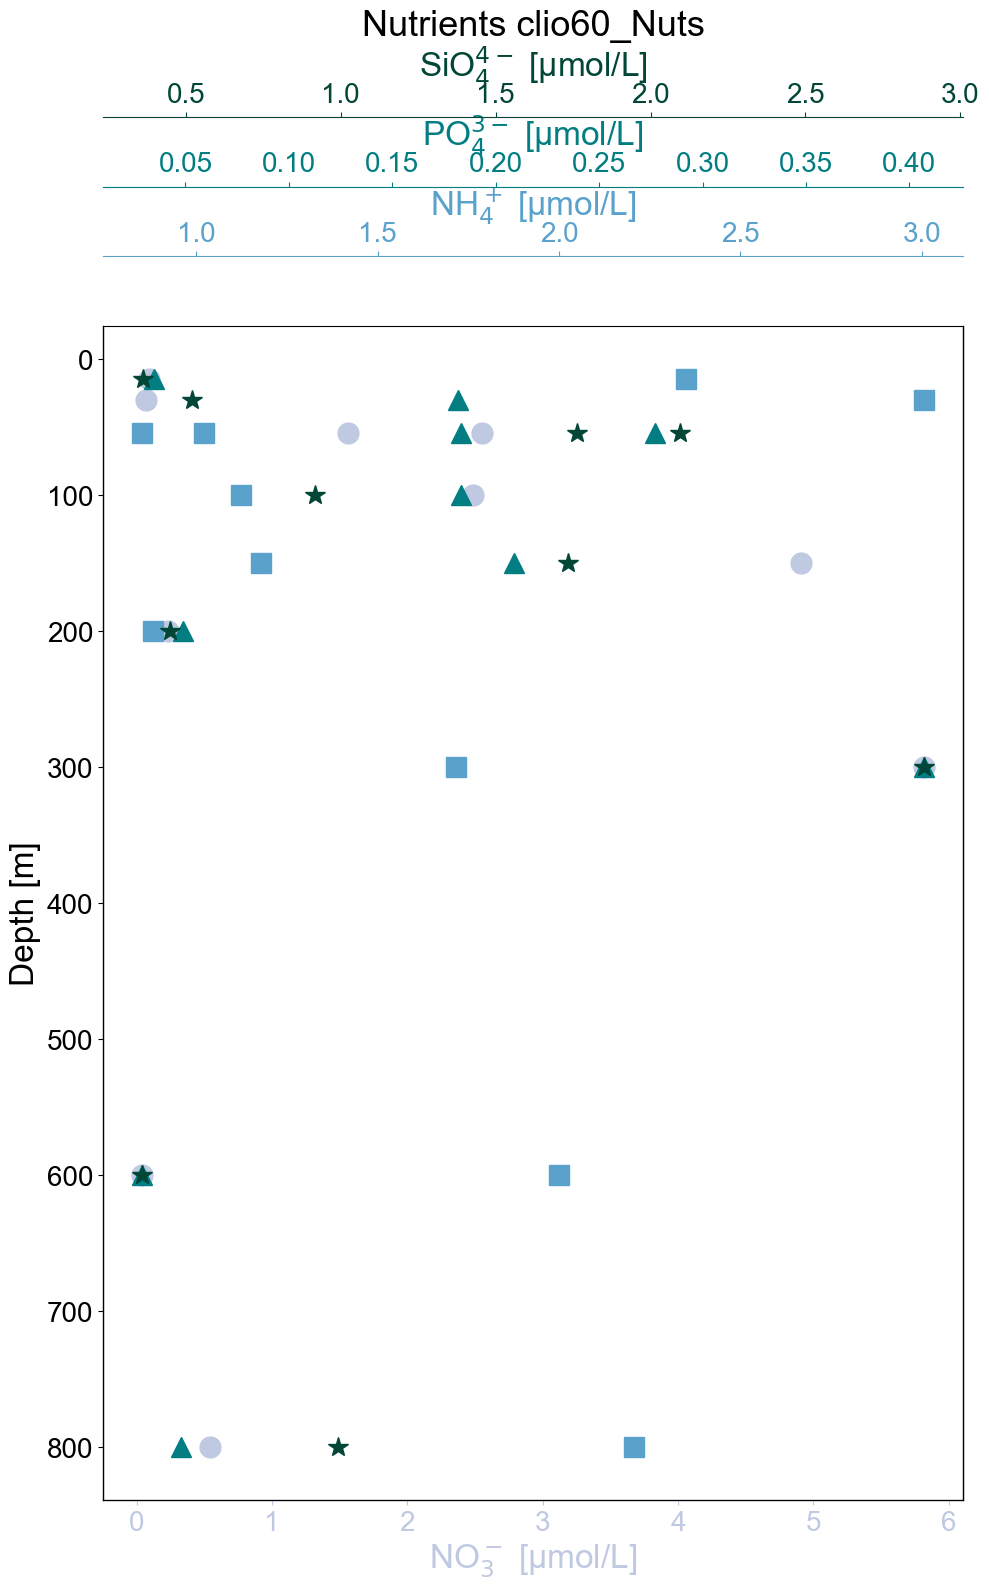

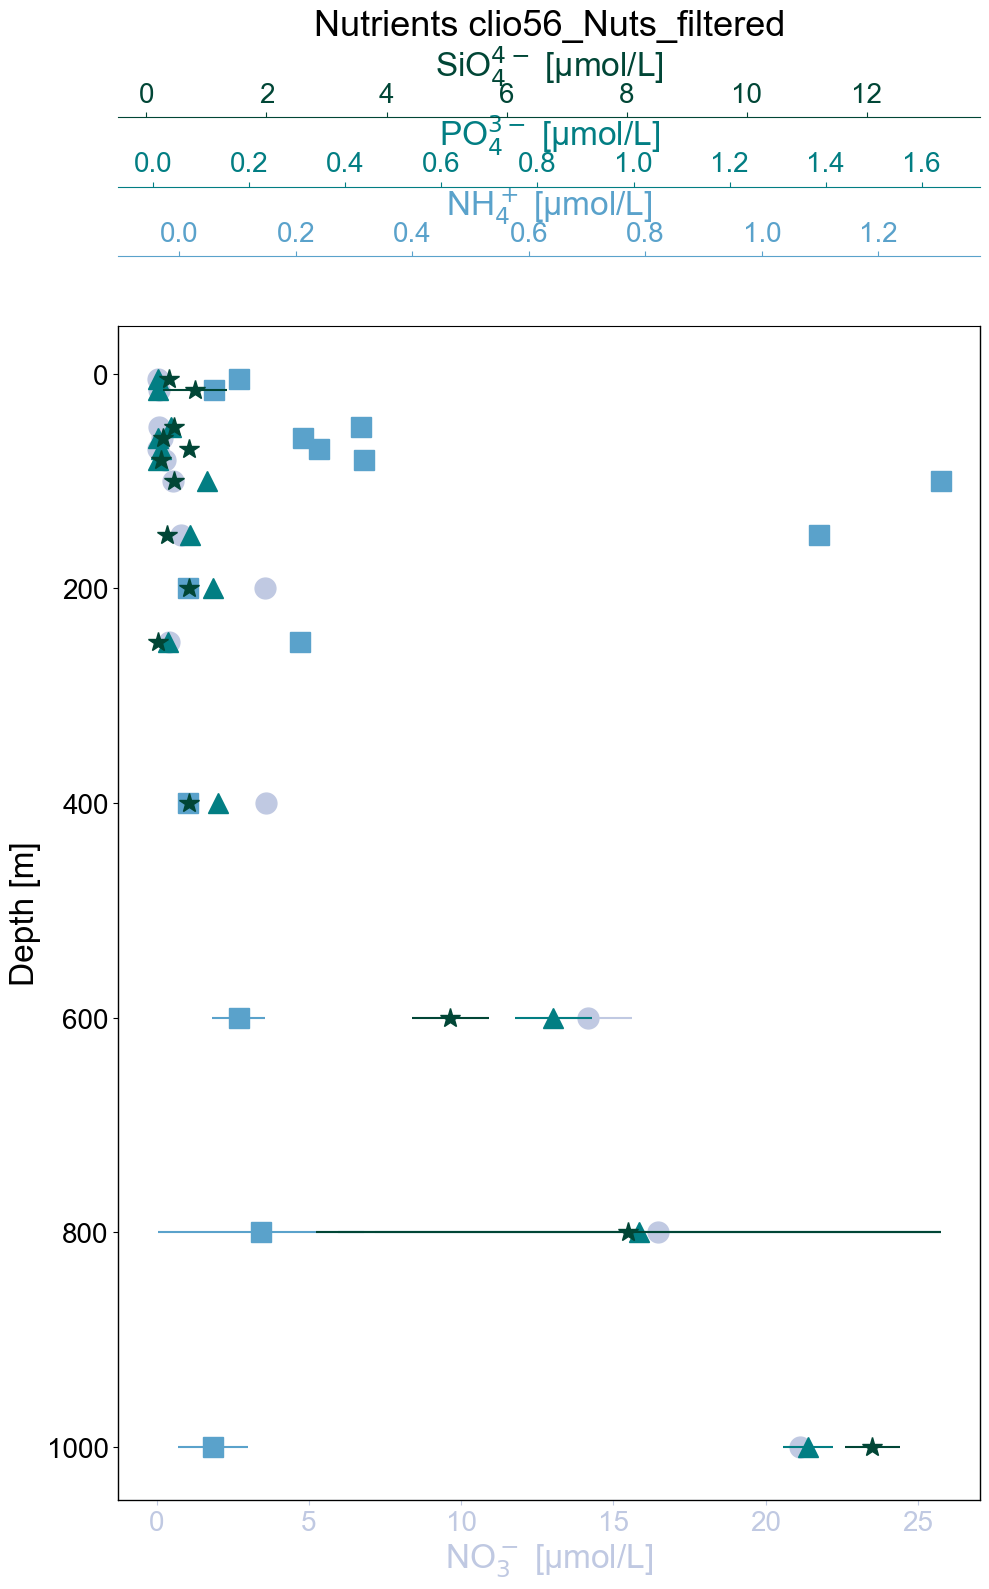

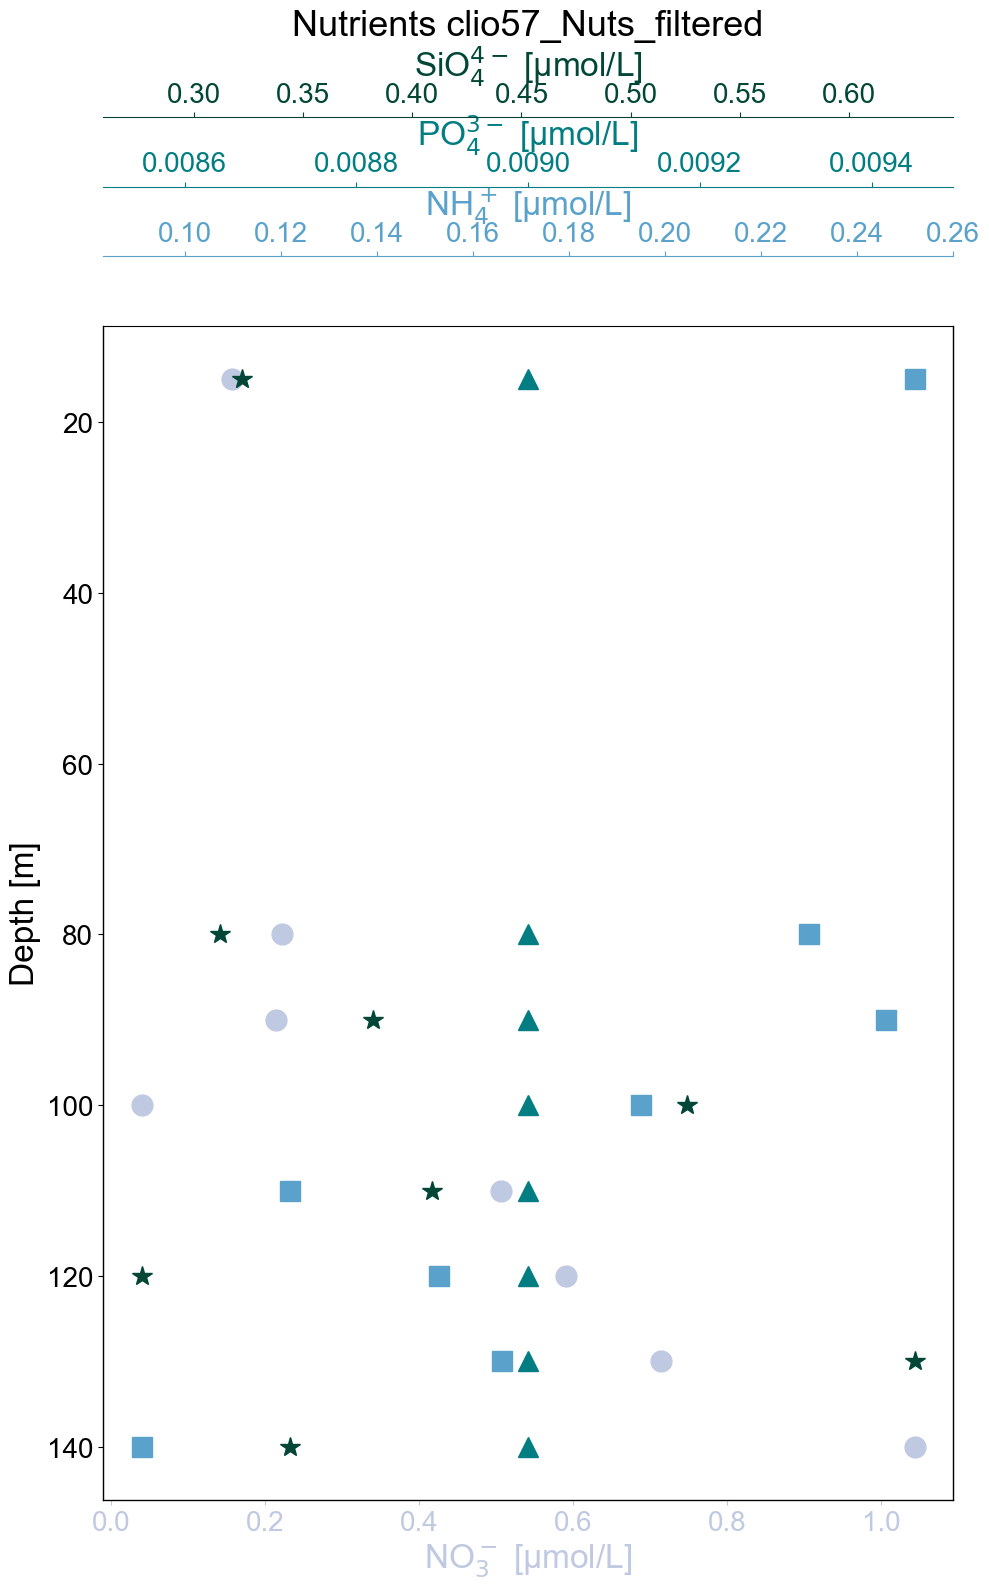

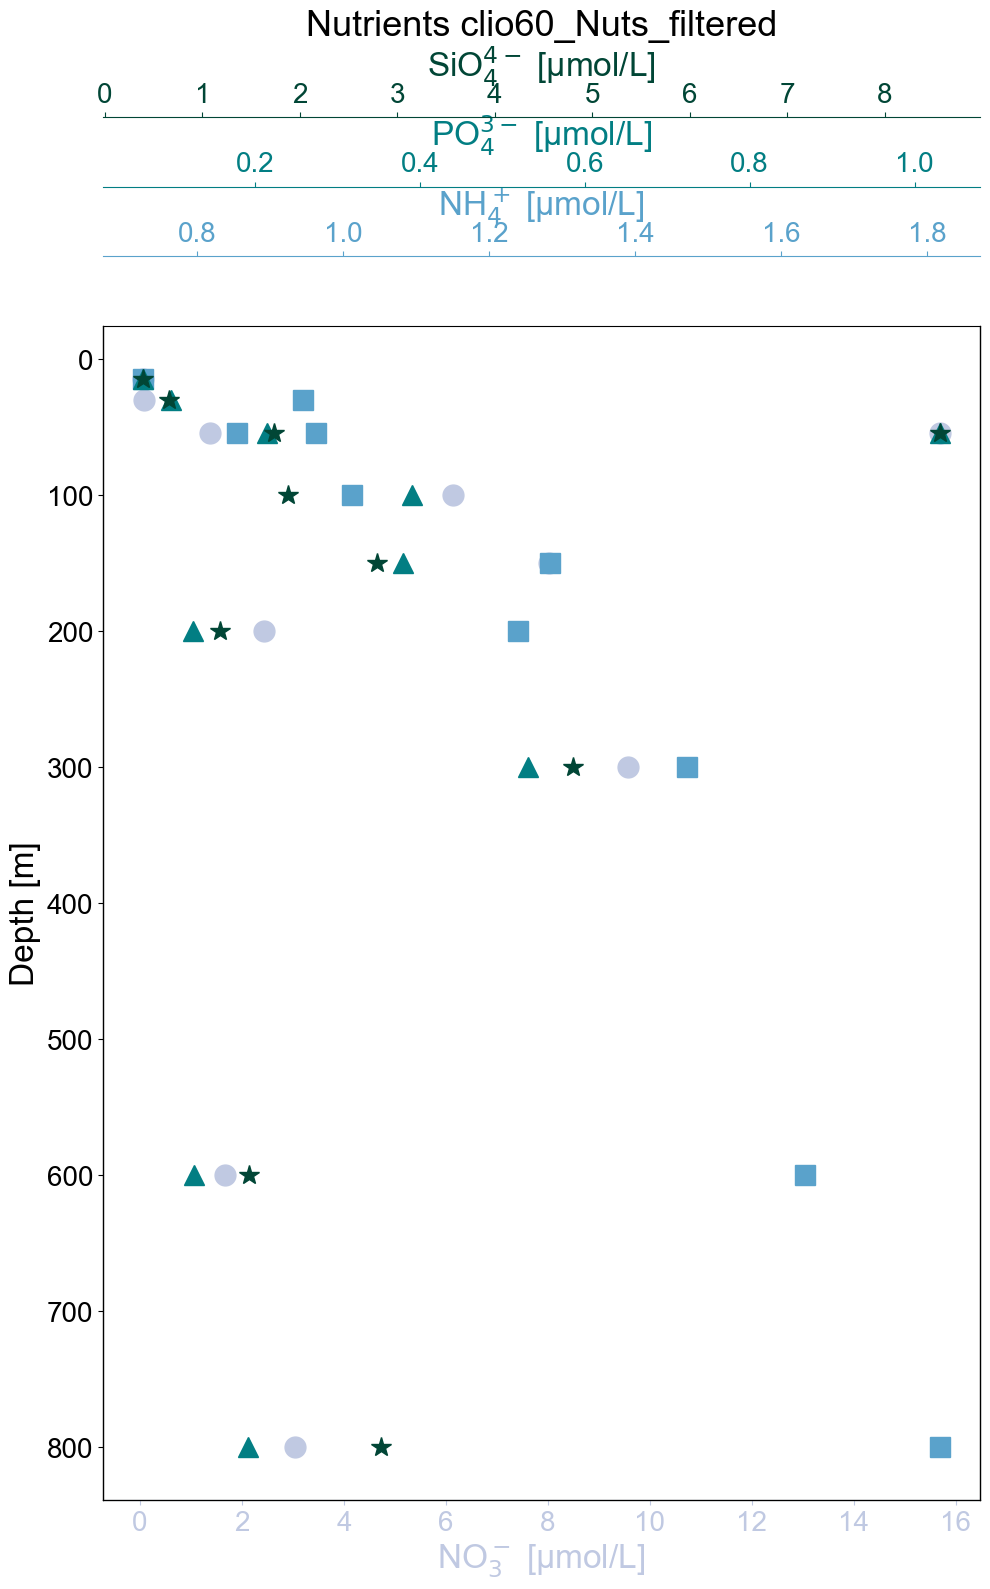

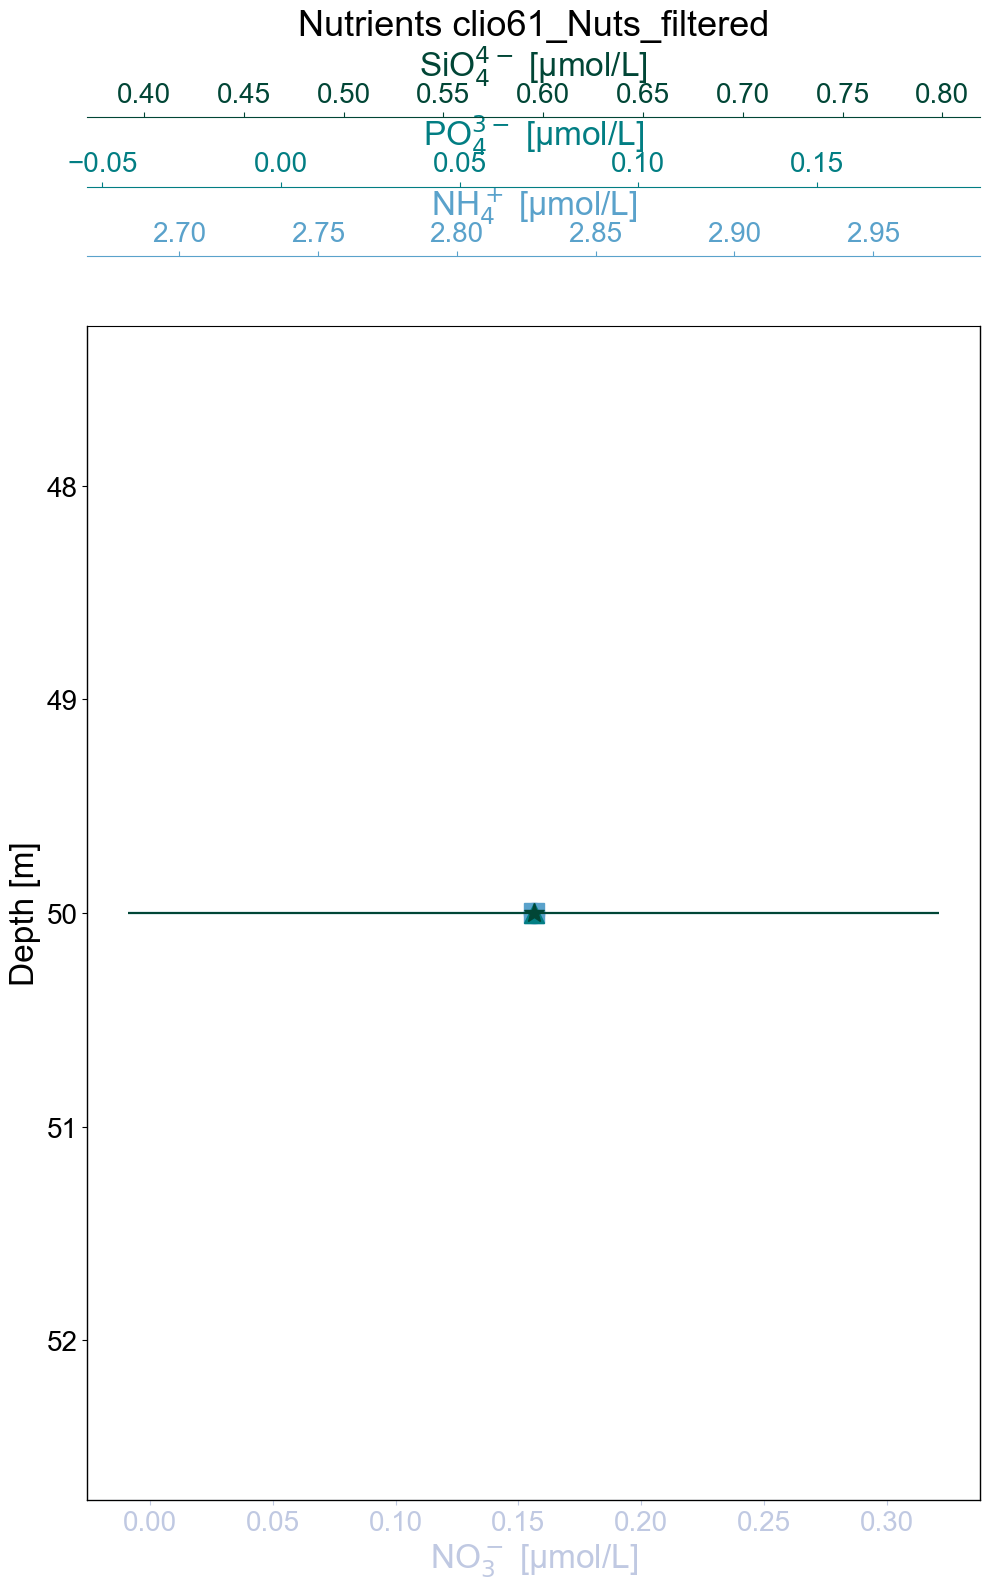

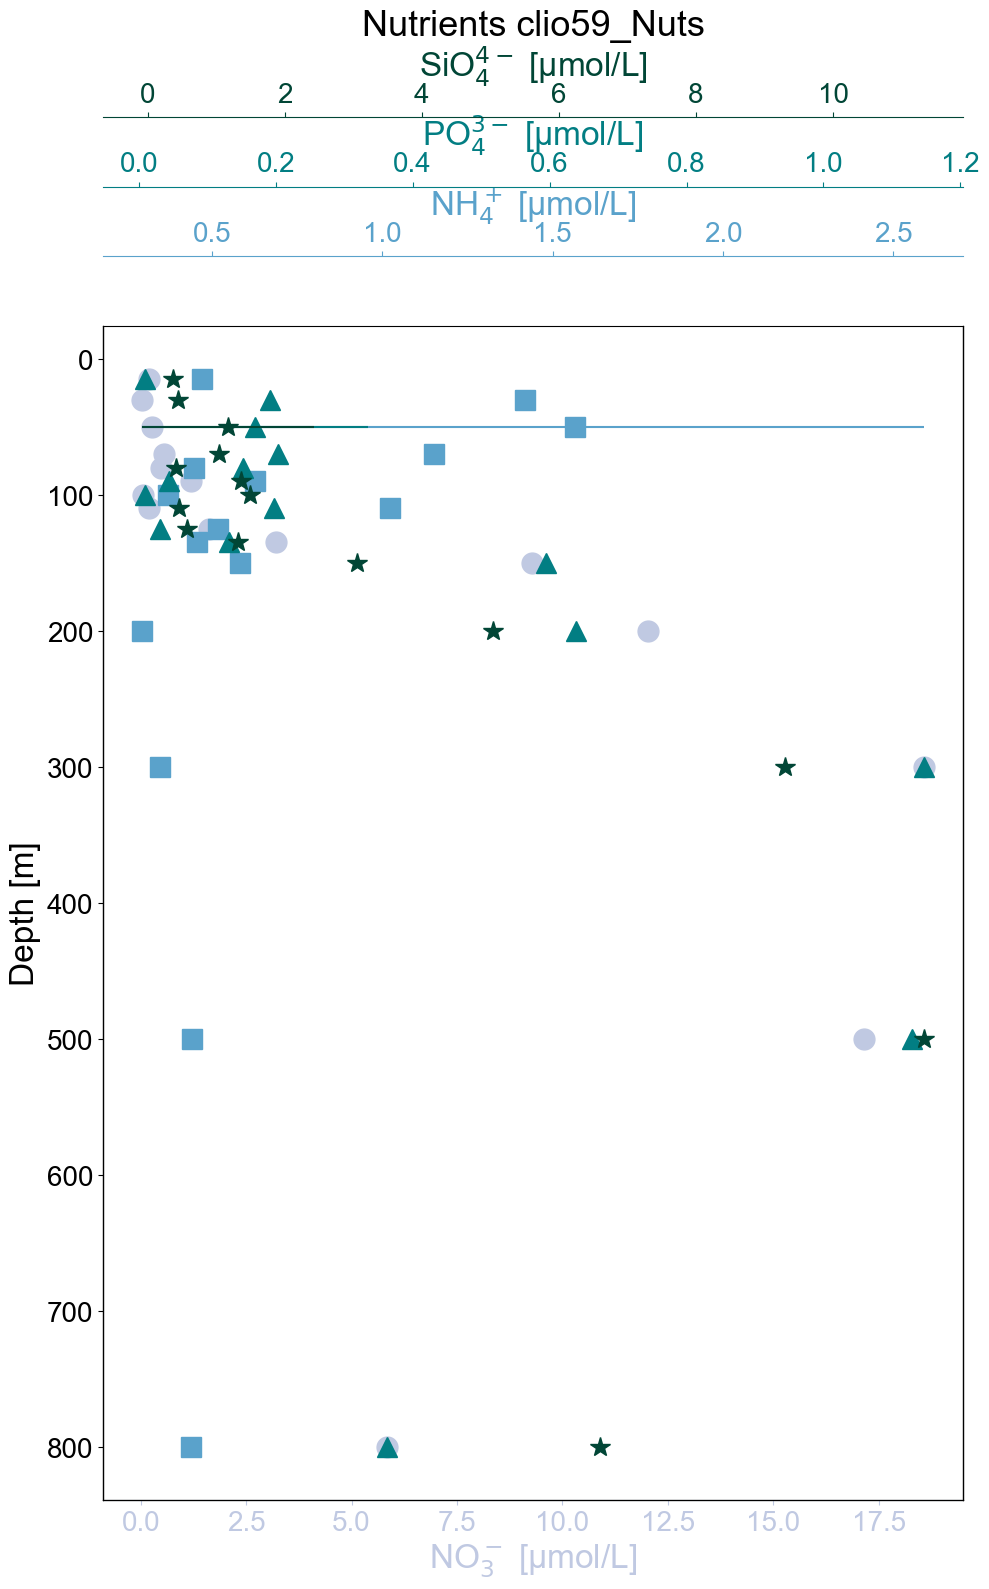

In [14]:
for key, df in nut_dic.items():
    cmap = plt.get_cmap("PuBuGn")
    colors = cmap(np.linspace(0.3, 1, 4))
    # Group replicates by depth
    grouped = df.groupby("Depth").agg(["mean", "std"])
    depth = grouped.index

    # Create main axis
    fig, ax1 = plt.subplots(figsize=(10, 16))

    # --- NO3 --- (main axis)
    ax1.errorbar(
        grouped[r"Nitrate+NO2"]["mean"], depth,
        xerr=grouped["Nitrate+NO2"]["std"],
        fmt='o', markersize=15, color=colors[0], label=r"NO$_3^-$"
    )
    ax1.set_xlabel(r"NO$_3^-$ [µmol/L]", fontsize=24, color=colors[0])
    ax1.tick_params(axis='x', colors=colors[0], labelsize=20)
    ax1.spines['bottom'].set_color(colors[0])
    ax1.xaxis.label.set_color(colors[0])

    # Create twin axes for other nutrients
    ax2 = ax1.twiny()
    ax3 = ax1.twiny()
    ax4 = ax1.twiny()

    # Offset the twin axes so they don’t overlap
    ax2.spines["top"].set_position(("outward", 50))
    ax3.spines["top"].set_position(("outward", 100))
    ax4.spines["top"].set_position(("outward", 150))

    # --- NH4 ---
    ax2.errorbar(
        grouped["Ammonium"]["mean"], depth,
        xerr=grouped["Ammonium"]["std"],
        fmt='s', markersize=15, color=colors[1], label=r"NH$_4^+$"
    )
    ax2.set_xlabel(r"NH$_4^+$ [µmol/L]", fontsize=24, color=colors[1])
    ax2.tick_params(axis='x', colors=colors[1], labelsize=20)
    ax2.spines['top'].set_color(colors[1])
    ax2.xaxis.label.set_color(colors[1])

    # --- PO4 ---
    ax3.errorbar(
        grouped["Phosphate"]["mean"], depth,
        xerr=grouped["Phosphate"]["std"],
        fmt='^', markersize=15, color=colors[2], label=r"PO$_4^{3-}$"
    )
    ax3.set_xlabel(r"PO$_4^{3-}$ [µmol/L]", fontsize=24, color=colors[2])
    ax3.tick_params(axis='x', colors=colors[2], labelsize=20)
    ax3.spines['top'].set_color(colors[2])
    ax3.xaxis.label.set_color(colors[2])

    # --- SiO4 ---
    ax4.errorbar(
        grouped["Silicate"]["mean"], depth,
        xerr=grouped["Silicate"]["std"],
        fmt='*', markersize=15, color=colors[3], label=r"SiO$_4$"
    )
    ax4.set_xlabel(r"SiO$_4^{4-}$ [µmol/L]", fontsize=24, color=colors[3])
    ax4.tick_params(axis='x', colors=colors[3], labelsize=20)
    ax4.spines['top'].set_color(colors[3])
    ax4.xaxis.label.set_color(colors[3])

    # Depth orientation
    ax1.set_ylabel("Depth [m]", fontsize=24)
    ax1.tick_params(axis='y', labelsize=20)
    ax1.invert_yaxis()
    
    # Title
    plt.title(f"Nutrients {key}", fontsize=26)

    plt.tight_layout()
    plt.savefig(f'../5_figures/{key}.pdf', format='pdf')
    plt.show()


## Only one nutrient per plot but samples in same plot

In [28]:
def profile_nuts(nut_dic, nutrient='NO3'):

    colors = plt.get_cmap("PuBuGn")(np.linspace(0.3, 1, len(nut_dic)))

    nutrient_info = {
        'NO3': {
            'column': 'Nitrate+NO2',
            'label': r'NO$_3^-$ [µmol/L]',
            'marker': 'o'},
        'NH4': {
            'column': 'Ammonium',
            'label': r'NH$_4^+$ [µmol/L]',
            'marker': 's'},
        'PO4': {
            'column': 'Phosphate',
            'label': r'PO$_4^{3-}$ [µmol/L]',
            'marker': '^'},
        'SiO4': {
            'column': 'Silicate',
            'label': r'SiO$_4$ [µmol/L]',
            'marker': '*'}}

    info = nutrient_info[nutrient]

    fig, ax = plt.subplots(figsize=(10, 16))

    for (key, df), color in zip(nut_dic.items(), colors):

        grouped = df.groupby("Depth").agg(["mean", "std"])
        depth = grouped.index

        ax.errorbar(
            grouped[info['column']]["mean"],
            depth,
            xerr=grouped[info['column']]["std"],
            fmt=info['marker'],
            markersize=15,
            color=color,
            label=key
        )

    ax.set_xlabel(info['label'], fontsize=24)
    ax.set_ylabel("Depth [m]", fontsize=24)

    ax.tick_params(axis='both', labelsize=20)

    ax.invert_yaxis()

    ax.legend(fontsize=18)

    plt.title(f"{nutrient}", fontsize=26)

    plt.tight_layout()

    plt.savefig(
        f'../5_figures/1_nutrients/unfiltered_{nutrient}.pdf',
        format='pdf'
    )
    plt.show()

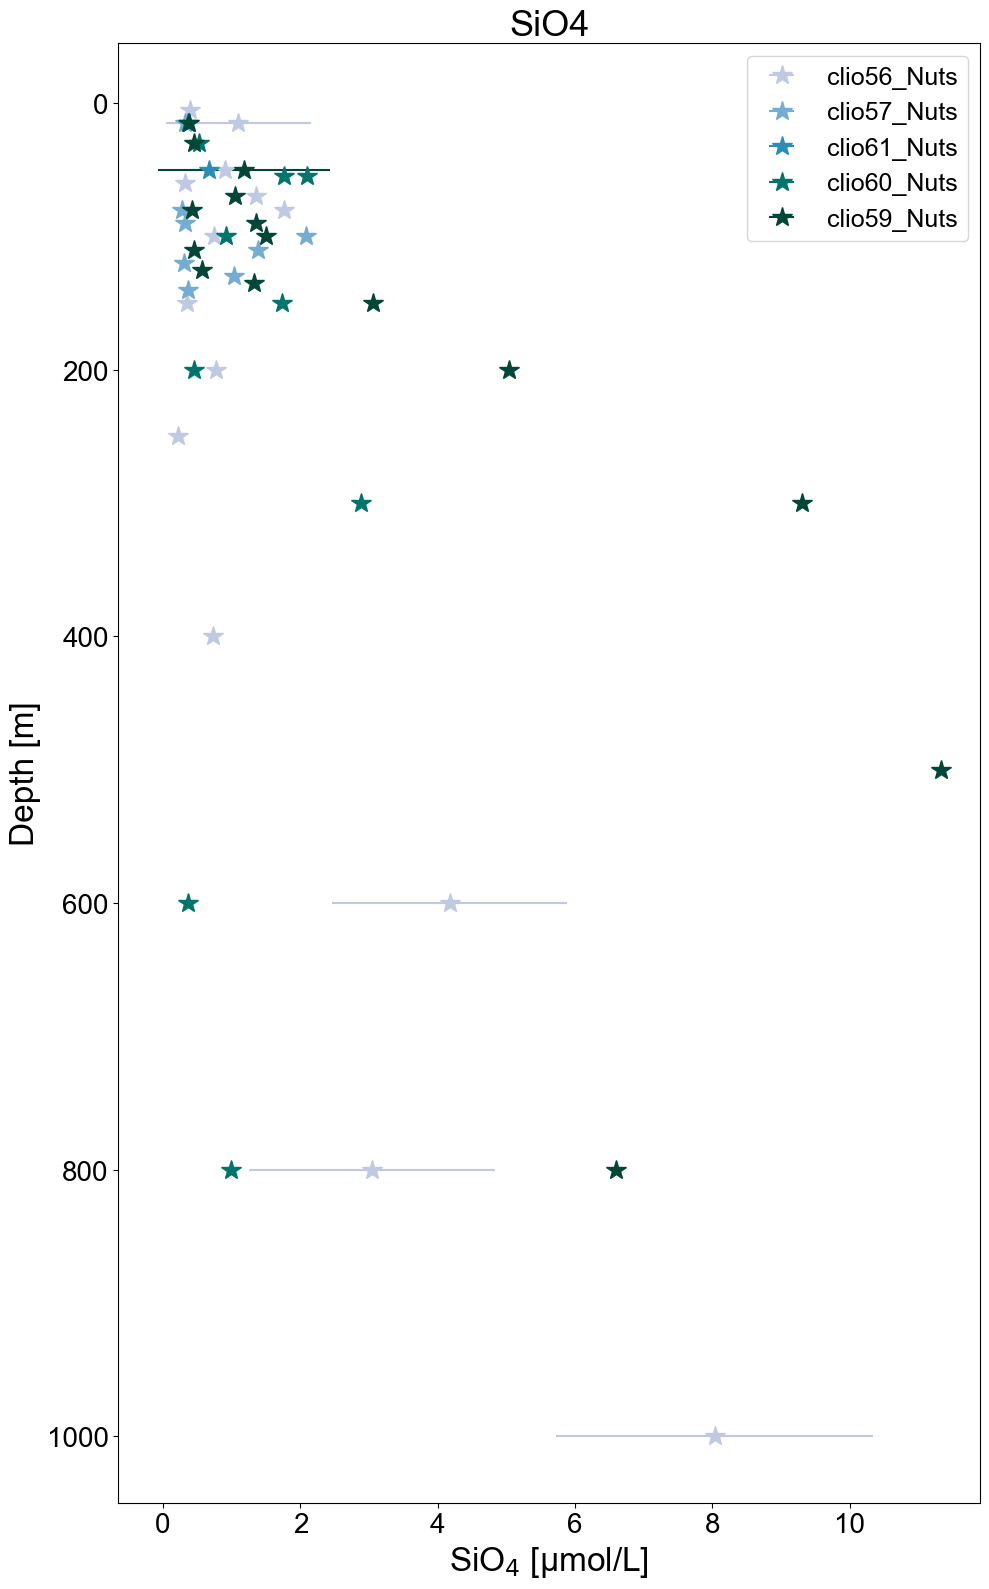

In [32]:
profile_nuts(nutrients_unfiltered, nutrient='SiO4')

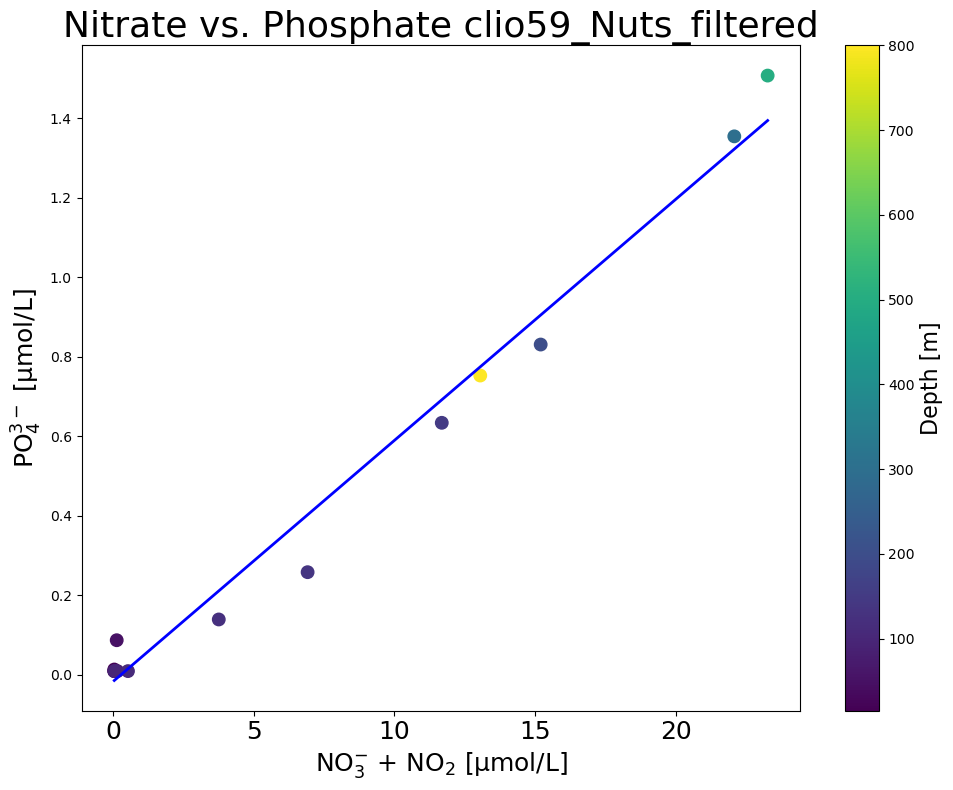

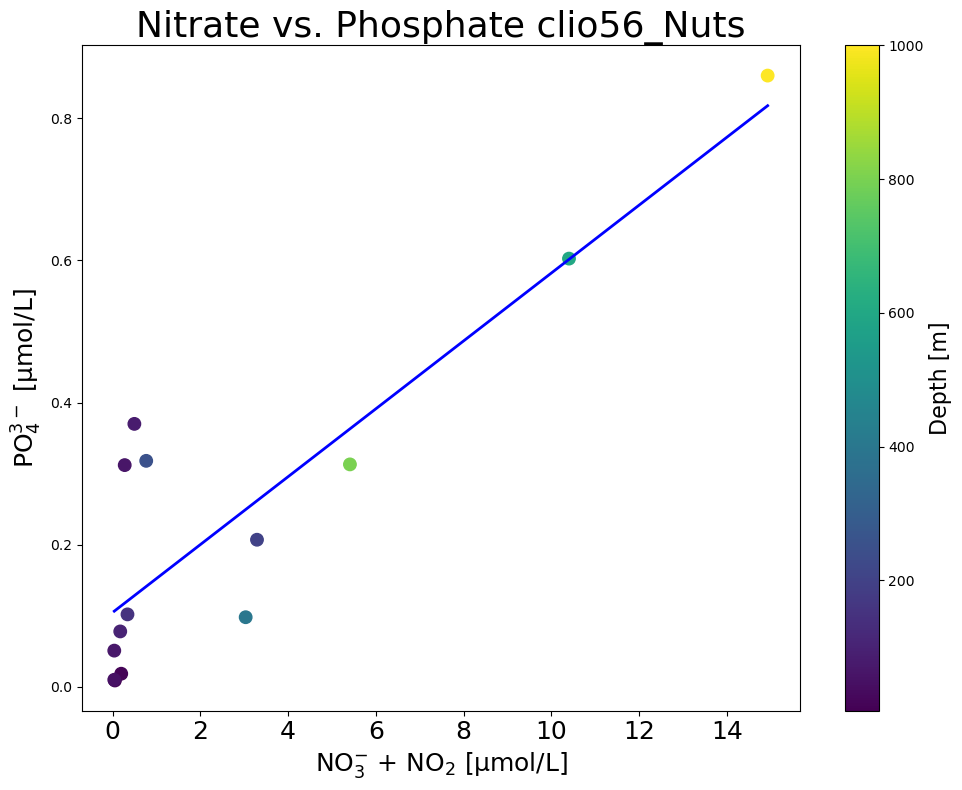

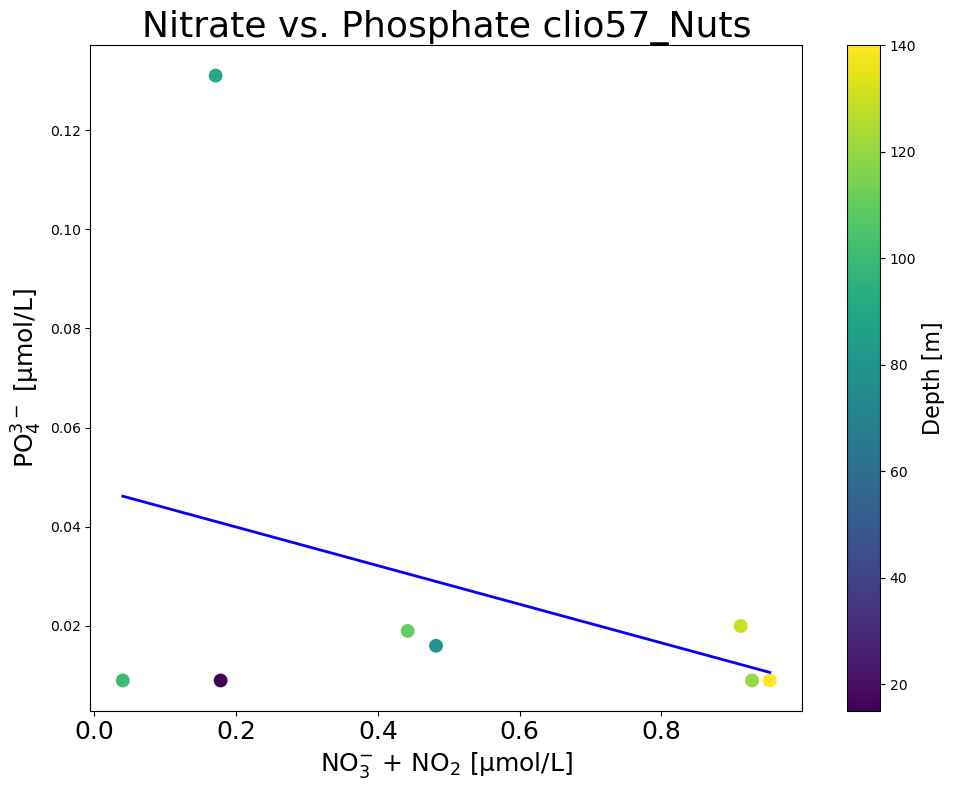

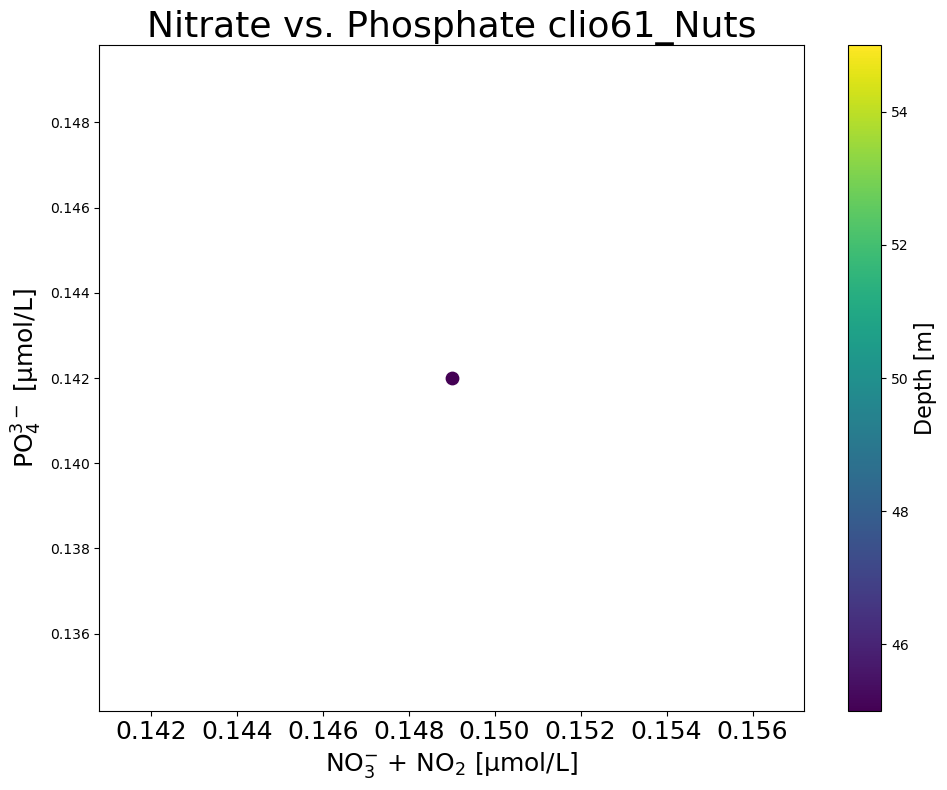

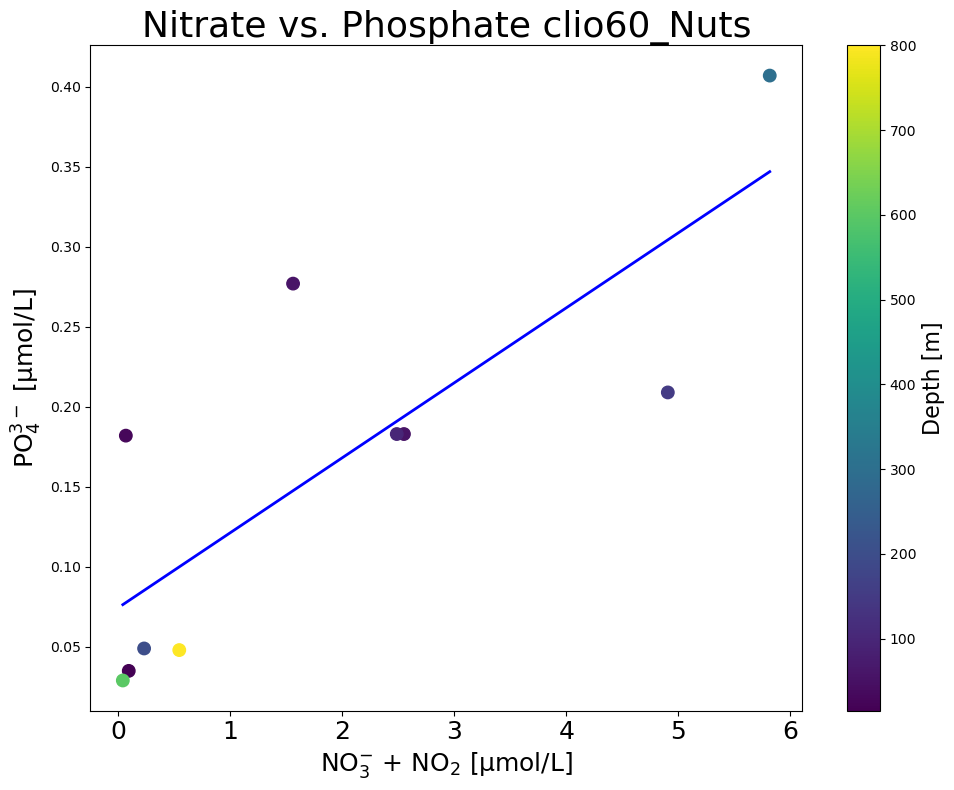

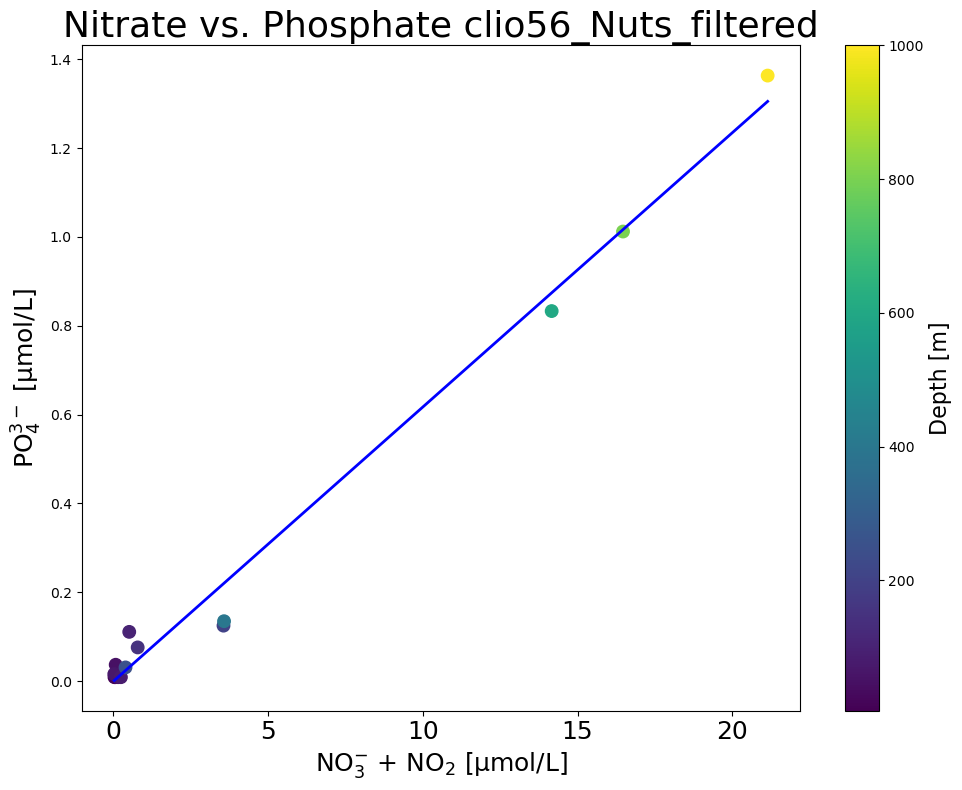

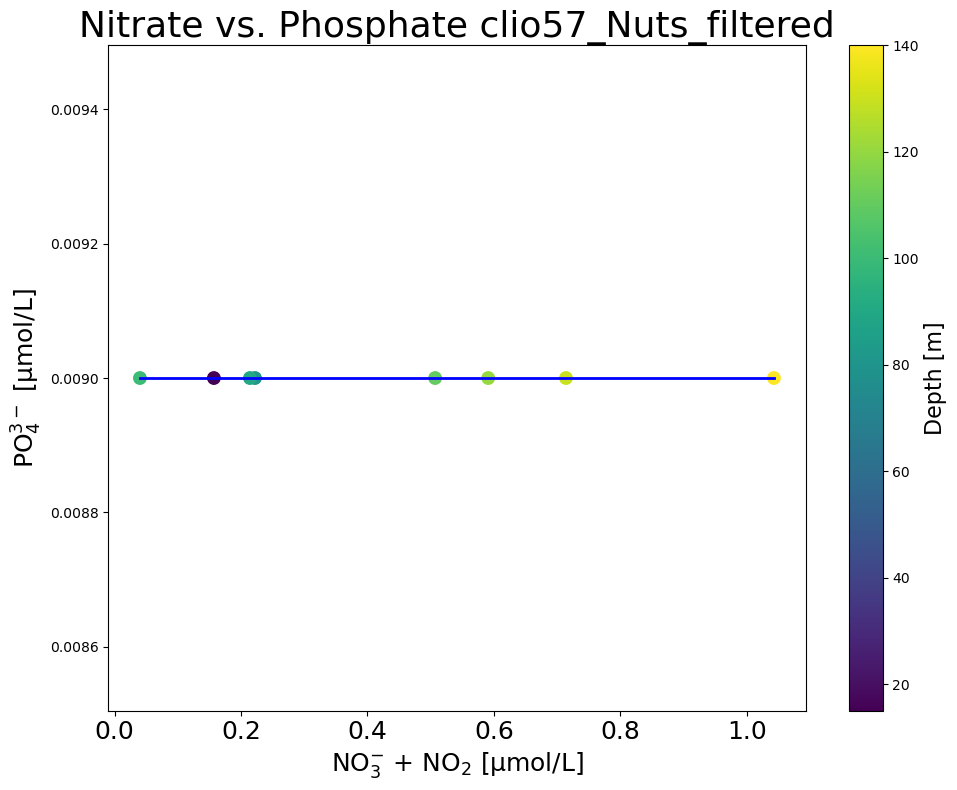

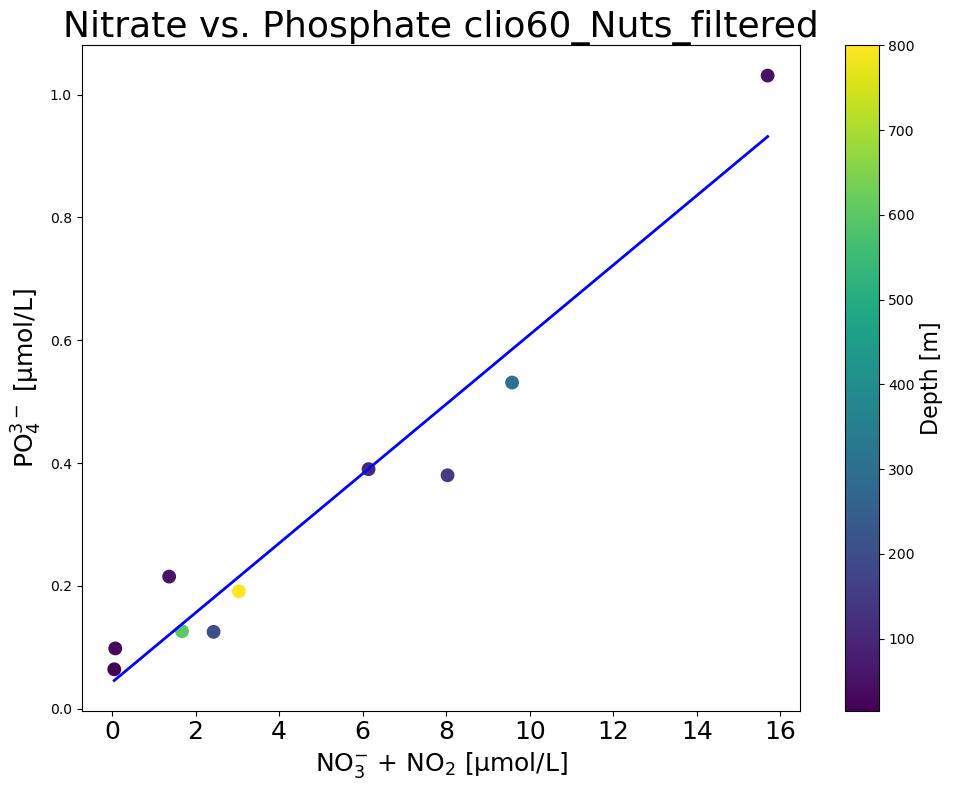

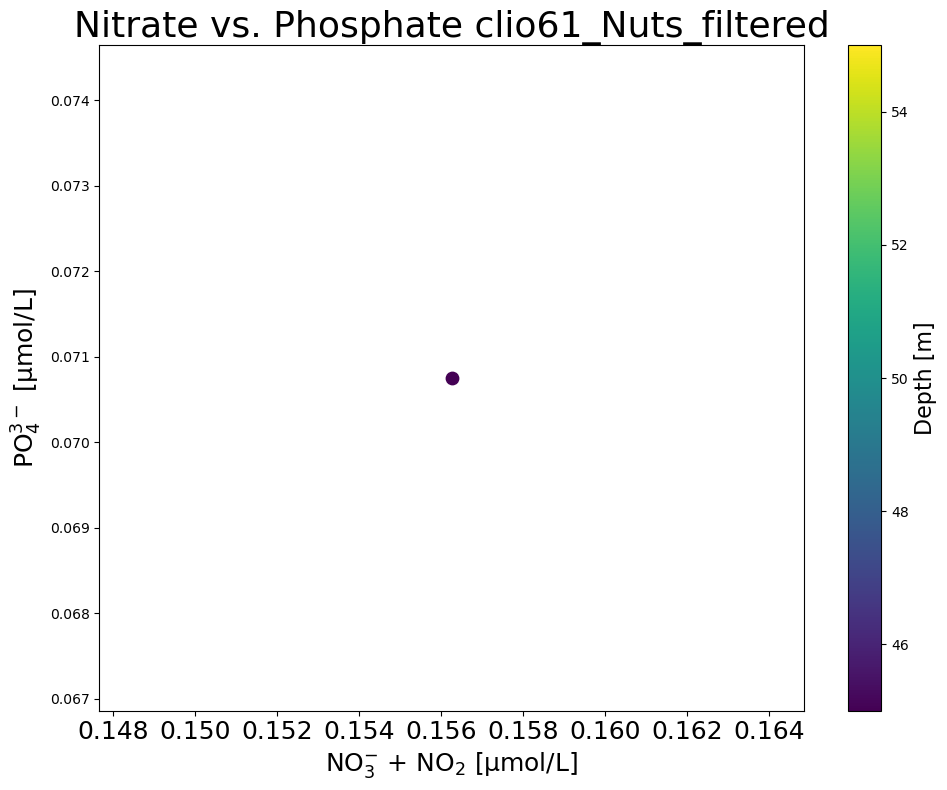

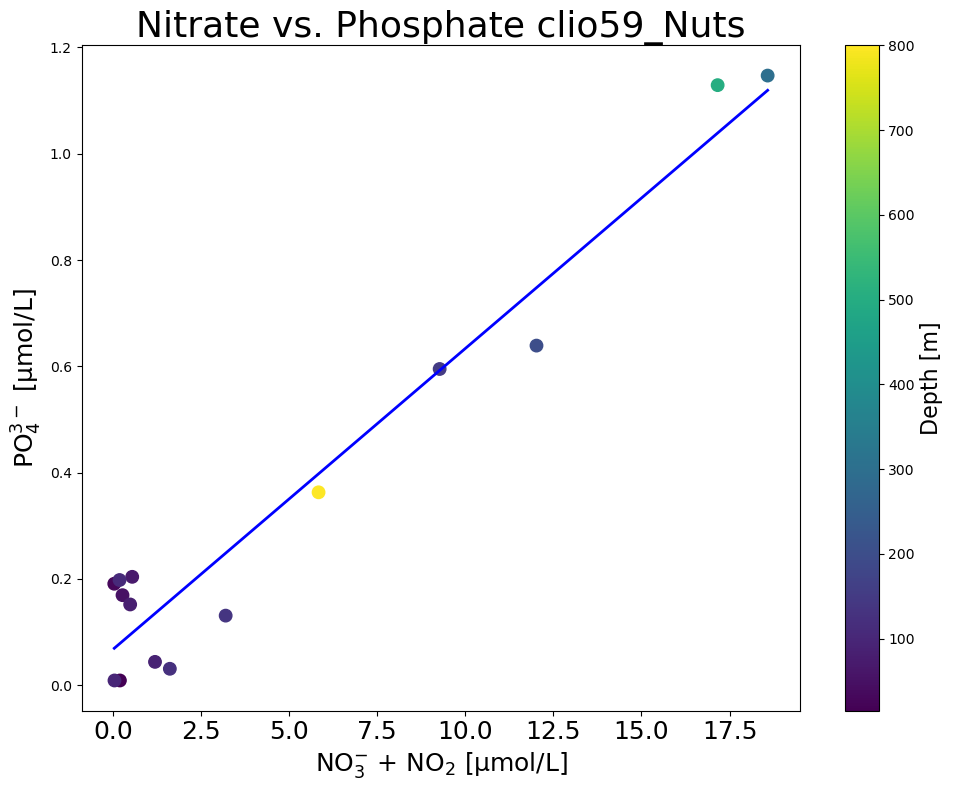

In [64]:
for key, df in nut_dic.items():

    # Group replicates by depth
    grouped = df.groupby("Depth").agg(["mean", "std"])
    
    x = grouped[r"Nitrate+NO2"]["mean"].values.reshape(-1, 1)
    y = grouped[r"Phosphate"]["mean"].values
    depths = grouped.index.values  # depth labels for coloring

    # Fit regression
    reg = LinearRegression().fit(x, y)
    x_line = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
    y_line = reg.predict(x_line)

    # Create colormap (one color per depth)
    cmap = plt.get_cmap("viridis")
    norm = plt.Normalize(vmin=depths.min(), vmax=depths.max())
    colors = cmap(norm(depths))

    fig, ax = plt.subplots(figsize=(10, 8))

    sc = ax.scatter(x, y, c=colors, s=80)
    
    # Regression line
    ax.plot(x_line, y_line, linewidth=2, color="blue")
    
    # Colorbar (use same Axes!)
    cbar = fig.colorbar(
        plt.cm.ScalarMappable(norm=norm, cmap=cmap),
        ax=ax
    )
    cbar.set_label("Depth [m]", fontsize=16)
    
    ax.set_xlabel(r"NO$_3^{-}$ + NO$_2$ [µmol/L]", fontsize=18)
    ax.set_ylabel(r"PO$_4^{3-}$ [µmol/L]", fontsize=18)
    ax.tick_params(axis='x', labelsize=18)
    
    ax.set_title(f"Nitrate vs. Phosphate {key}", fontsize=26)
    
    fig.tight_layout()
    #fig.savefig(f'../figures/NitvsPhos_{key}.pdf', format="pdf")
    plt.show()

/Users/fadimestemmer/miniconda3/envs/AE25/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/Users/fadimestemmer/miniconda3/envs/AE25/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/var/folders/hb/hntvhz5j0j15vb_5h21tbhph0000gn/T/ipykernel_25950/3506103216.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


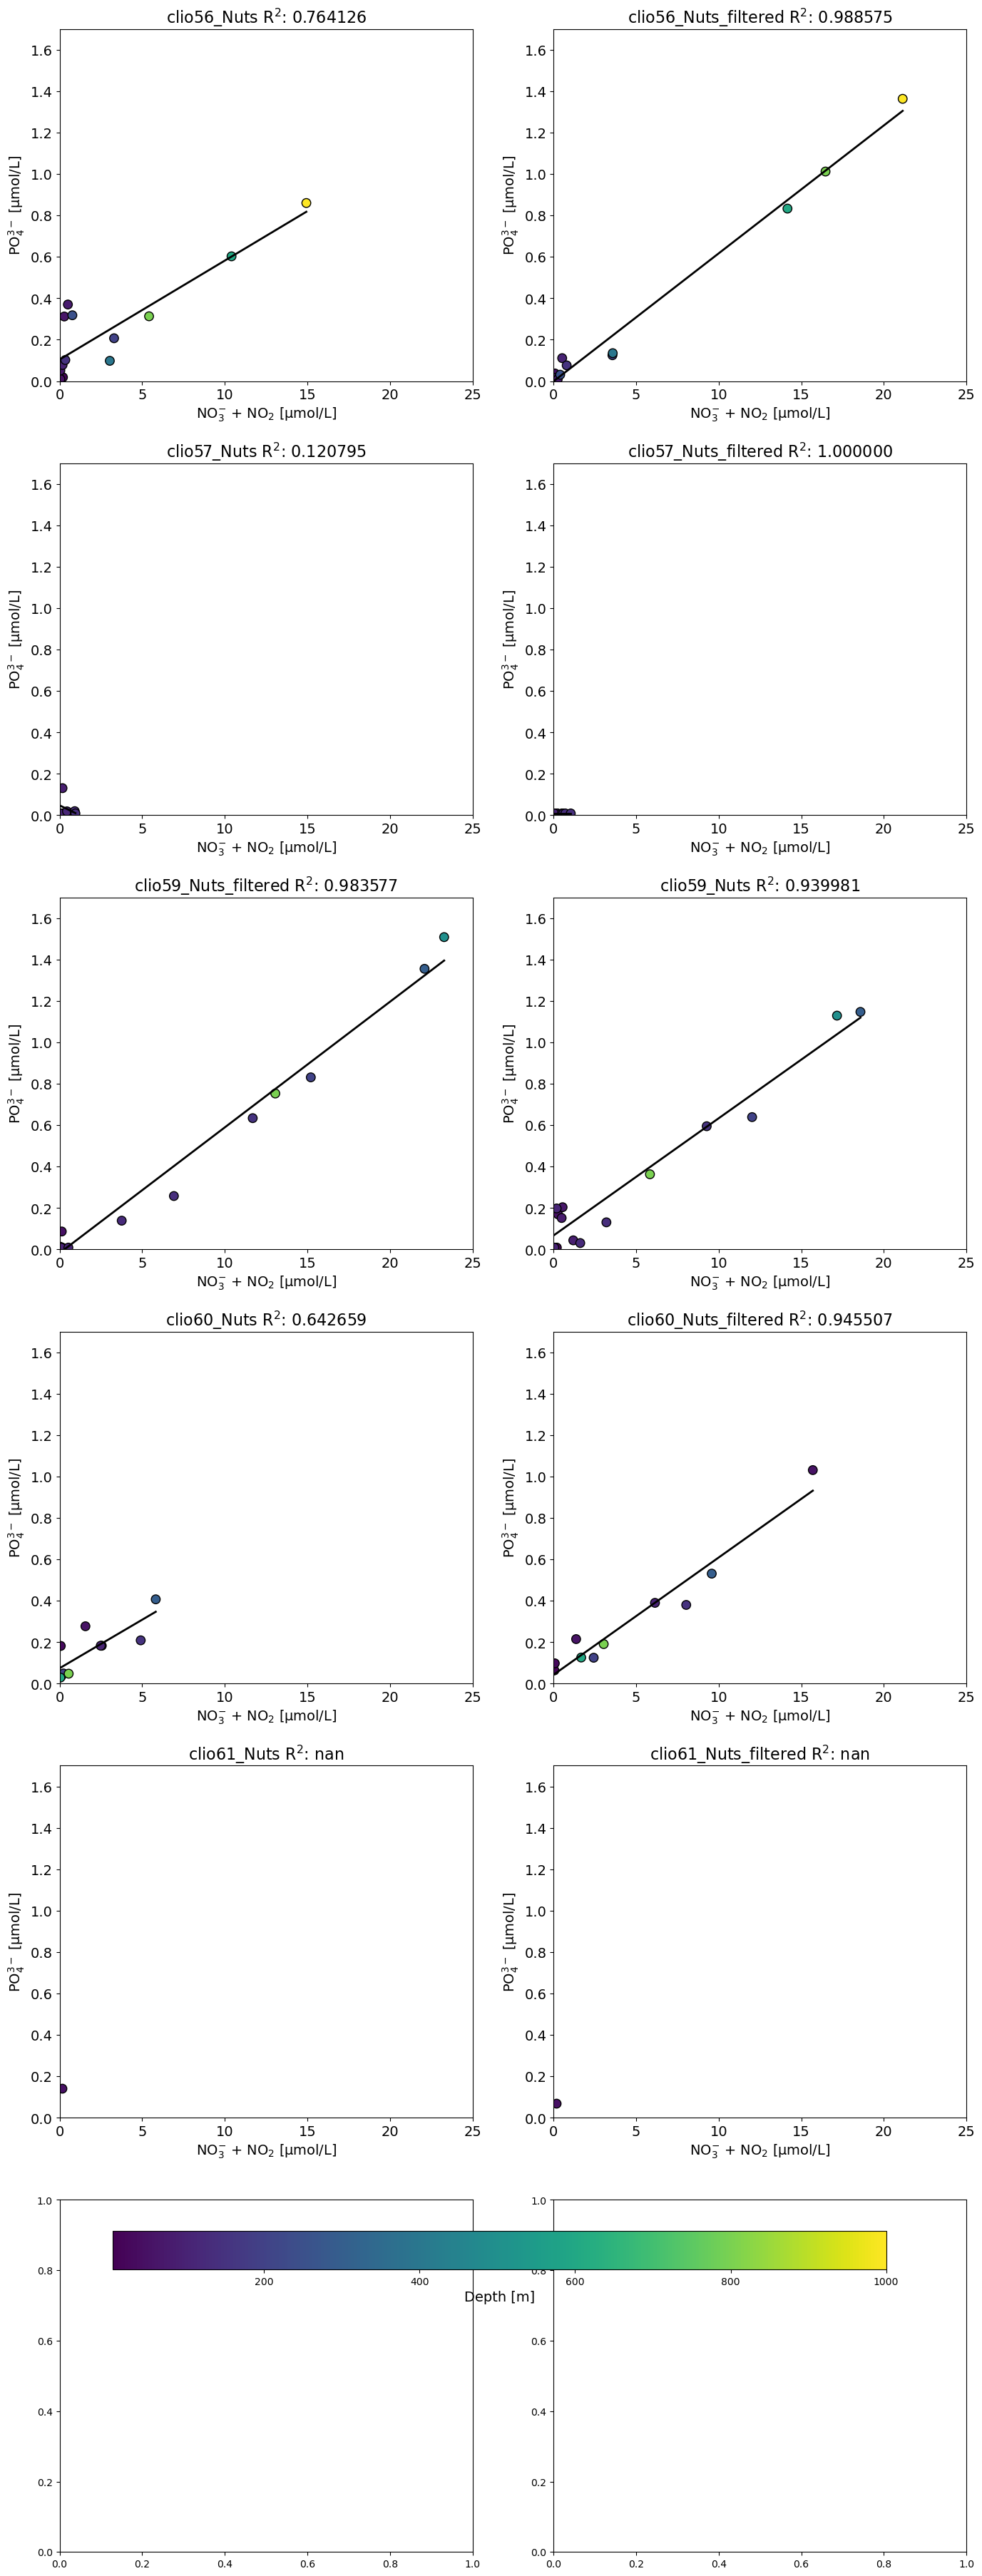

In [96]:
# --- Sort keys naturally, e.g., clio56, clio57, clio59 ---
def natural_sort_key(s):
    # Split into text and numbers for proper numeric sorting
    match = re.search(r'(\D+)(\d+)', s)
    if match:
        prefix, num = match.groups()
        return (prefix, int(num))
    else:
        return (s, 0)

sorted_keys = sorted(nut_dic.keys(), key=natural_sort_key)

# --- 1. Compute global depth range ---
all_depths = np.concatenate([df["Depth"].unique() for df in nut_dic.values()])
global_min = all_depths.min()
global_max = all_depths.max()

cmap = plt.get_cmap("viridis")  # colormap
norm = plt.Normalize(global_min, global_max)

# --- 2. Prepare subplots ---
n_plots = len(nut_dic)
ncols = 2
nrows = 6
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*7, nrows*6))
axes = axes.flatten()  # flatten in case of multiple rows

# --- Sort keys naturally, e.g., clio56, clio57, clio59 ---
def natural_sort_key(s):
    # Split into text and numbers for proper numeric sorting
    match = re.search(r'(\D+)(\d+)', s)
    if match:
        prefix, num = match.groups()
        return (prefix, int(num))
    else:
        return (s, 0)

sorted_keys = sorted(nut_dic.keys(), key=natural_sort_key)

# --- 3. Loop through datasets in sorted order ---
for ax, key in zip(axes, sorted_keys):
    df = nut_dic[key]
    
    # Group replicates by depth
    grouped = df.groupby("Depth").agg(["mean", "std"])
    
    x = grouped[r"Nitrate+NO2"]["mean"].values
    x_reshaped = x.reshape(-1,1)
    y = grouped[r"Phosphate"]["mean"].values
    depths = grouped.index.values
    
    # Color based on global depth range
    colors = cmap(norm(depths))
    
    # Scatter
    sc = ax.scatter(x, y, c=colors, s=80, edgecolor="black")
    
    # Linear regression
    reg = LinearRegression().fit(x.reshape(-1,1), y)
    slope = reg.coef_[0]
    R = reg.score(x_reshaped, y)
    intercept = reg.intercept_
    x_line = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
    y_line = reg.predict(x_line)
    ax.plot(x_line, y_line, color="black", linewidth=2)
    
    # Labels and title
    ax.set_xlabel(r"NO$_3^{-}$ + NO$_2$ [µmol/L]", fontsize=14)
    ax.set_xlim(0, 25)
    ax.set_ylabel(r"PO$_4^{3-}$ [µmol/L]", fontsize=14)
    ax.set_ylim(0, 1.7)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.set_title(f"{key} R$^{2}$: {R:2f}", fontsize=16)


# --- 4. Shared colorbar at the bottom ---
cbar = fig.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=cmap),
    ax=axes,
    location="bottom",
    fraction=0.025,   # width of the colorbar relative to figure
    pad = 0.1        # space between plots and colorbar
)
cbar.set_label("Depth [m]", fontsize=14)

fig.tight_layout()
fig.savefig('../figures/Nitrate_vs_Phosphate_All.pdf', format='pdf')
plt.show()